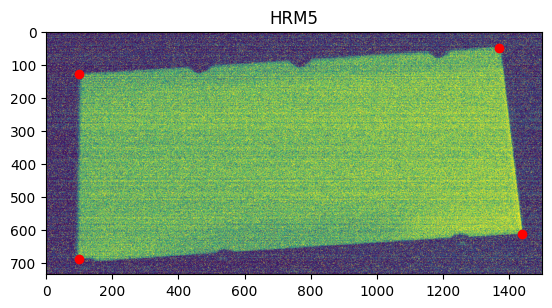

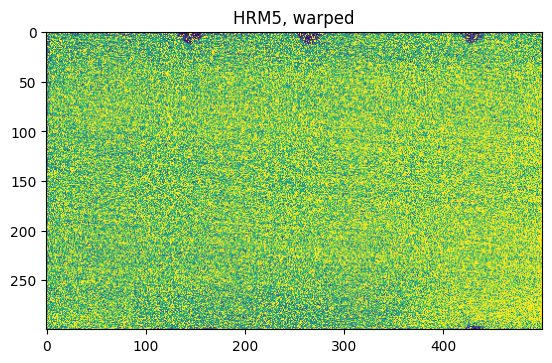

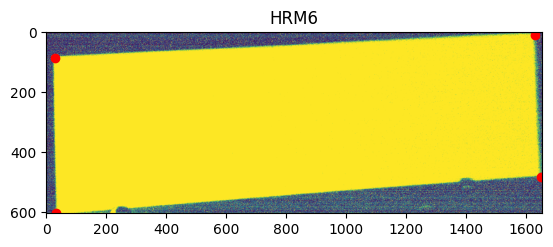

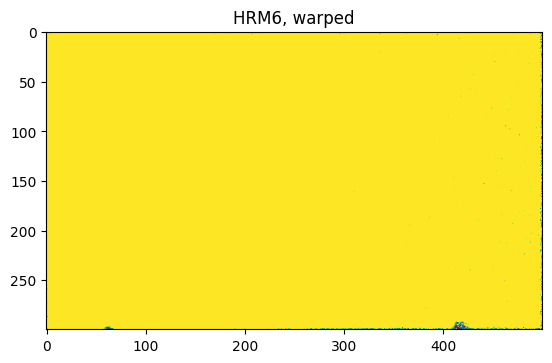

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

from skimage.transform import warp, ProjectiveTransform

sys.path.append('..')

hrm5_path = "../sample-data/hrm5.csv"
hrm6_path = "../sample-data/hrm6.csv"

H = 300
W = 500

img_dict = {
    
    # Path  to the image
    "PATH":{
        "HRM5":"../sample-data/hrm5.csv",
        "HRM6":"../sample-data/hrm6.csv",
    },

    # Four corners of the image
    "CORNERS":{
        # format (x,y)- note that x is the 1 axis, and y is the 0 axis
        "HRM5":[[100, 128], [1370, 48], [1440, 611], [100, 688]],
        "HRM6":[[28, 85], [1628, 8], [1648, 481], [33, 603]]
    },

    # Width of the screen in real life
    "WIDTH":{
        "HRM5":W,
        "HRM6":W,
    },

    # Height of screen in real life
    "HEIGHT":{
        "HRM5":H,
        "HRM6":H,
    }

}

DEST = np.array([[0,0], [W,0], [W,H], [0,H]])

def load_digicam_image(path:str)->tuple[np.ndarray, list, list]:
        #Remove top row and first column, as this is coordinate data
        try:
            img = np.genfromtxt(path, delimiter=',')
            x_coords = img[0, 1:]
            y_coords = img[1:, 0]
            img = img[1:, 1:]
            
            return img, x_coords, y_coords
        
        except Exception as e:
            ValueError(f"Error: DIGICAM image generation from {path} failed. {e}")

def plot_image(name, vmax):
    path = img_dict["PATH"][name]

    img, x, y = load_digicam_image(path=path)

    img = img / np.max(img)

    corners = img_dict["CORNERS"][name]

    tform = ProjectiveTransform()
    ok = tform.estimate(corners, DEST)
    if not ok:
        raise RuntimeError("Homography estimation failed")

    w = warp(
        img,
        inverse_map=tform.inverse,
        output_shape = (H, W),
        preserve_range = True 
    )

    plt.title(name)
    plt.imshow(img, vmax=vmax)
    for (x,y) in img_dict["CORNERS"][name]:
        plt.scatter(x, y, color='r')
    plt.show()

    plt.title(f"{name}, warped")
    plt.imshow(w, vmax=vmax)
    plt.show()

VMAX = 0.01
plot_image(name="HRM5", vmax=VMAX)
plot_image(name="HRM6", vmax=VMAX)